In [14]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/train_features.csv")

target = "SeriousDlqin2yrs"

X = df.drop(columns=[target])
y = df[target]

print(X.shape)
print(y.value_counts(normalize=True))

(149391, 35)
SeriousDlqin2yrs
0    0.933001
1    0.066999
Name: proportion, dtype: float64


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric="auc",
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


## Early Stopping + 学习曲线

固定 `n_estimators=300` 不能保证最优树数——树太少欠拟合，太多过拟合。  
用 `eval_set` + `early_stopping_rounds` 自动找最优轮数，并可视化训练过程中 AUC 的变化。

Early stopping 最优轮数: 164
验证集最优 AUC: 0.8660


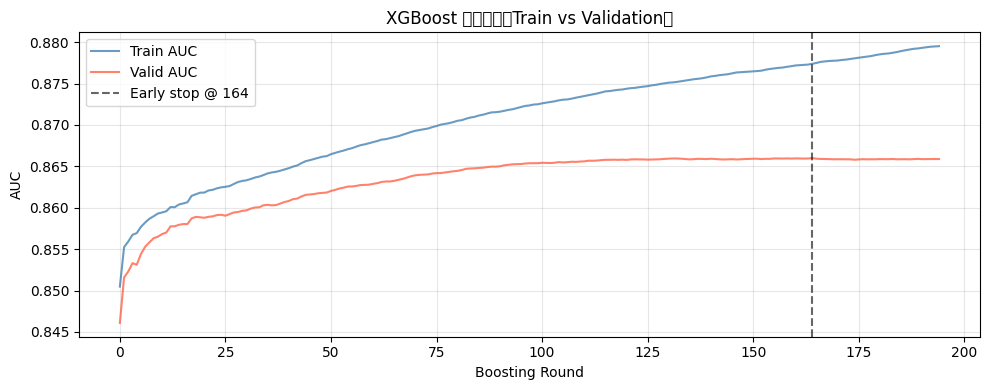

In [17]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

scale_pw = (y_train == 0).sum() / (y_train == 1).sum()

xgb_es = XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pw,
    base_score=0.5,              # 显式设置，避免新版 XGBoost 与 SHAP 的兼容性问题
    eval_metric='auc',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
)

xgb_es.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=False
)

best_round = xgb_es.best_iteration
best_auc   = xgb_es.best_score
print(f'Early stopping 最优轮数: {best_round}')
print(f'验证集最优 AUC: {best_auc:.4f}')

# 学习曲线
results   = xgb_es.evals_result()
train_auc = results['validation_0']['auc']
val_auc   = results['validation_1']['auc']

plt.figure(figsize=(10, 4))
plt.plot(train_auc, label='Train AUC', color='steelblue', alpha=0.8)
plt.plot(val_auc,   label='Valid AUC', color='tomato',    alpha=0.8)
plt.axvline(best_round, color='black', linestyle='--', alpha=0.6,
            label=f'Early stop @ {best_round}')
plt.xlabel('Boosting Round')
plt.ylabel('AUC')
plt.title('XGBoost 学习曲线（Train vs Validation）')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_model = xgb_es

## 超参数调优

在 Early Stopping 确认最优轮数后，对树结构相关参数做网格搜索。  
（如数据量较大可改用 Optuna 做贝叶斯搜索以节省时间）

In [18]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.03, 0.05, 0.1],
    'subsample':        [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
}

base_xgb = XGBClassifier(
    n_estimators=best_round,
    scale_pos_weight=scale_pw,
    base_score=0.5,              # 显式设置，避免新版 XGBoost 与 SHAP 的兼容性问题
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

gs = GridSearchCV(
    base_xgb, param_grid,
    cv=cv, scoring='roc_auc',
    n_jobs=-1, verbose=1, refit=True
)
gs.fit(X_train, y_train)

print(f'\n最优参数: {gs.best_params_}')
print(f'最优 CV ROC-AUC: {gs.best_score_:.4f}')

best_model = gs.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits

最优参数: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.7}
最优 CV ROC-AUC: 0.8655


In [19]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

y_pred = xgb_model.predict(X_valid)
y_proba = xgb_model.predict_proba(X_valid)[:, 1]

auc = roc_auc_score(y_valid, y_proba)

print("XGBoost ROC-AUC:", auc)
print(classification_report(y_valid, y_pred))
print(confusion_matrix(y_valid, y_pred))

XGBoost ROC-AUC: 0.8653086430017234
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27877
           1       0.22      0.78      0.34      2002

    accuracy                           0.79     29879
   macro avg       0.60      0.79      0.61     29879
weighted avg       0.93      0.79      0.84     29879

[[22172  5705]
 [  439  1563]]


## 完整指标评估（最优模型）

=== 最优 XGBoost 验证集评估 ===
ROC-AUC : 0.8659
PR-AUC  : 0.4045
Gini    : 0.7318

              precision    recall  f1-score   support

       正常(0)       0.98      0.79      0.88     27877
       违约(1)       0.21      0.79      0.34      2002

    accuracy                           0.79     29879
   macro avg       0.60      0.79      0.61     29879
weighted avg       0.93      0.79      0.84     29879



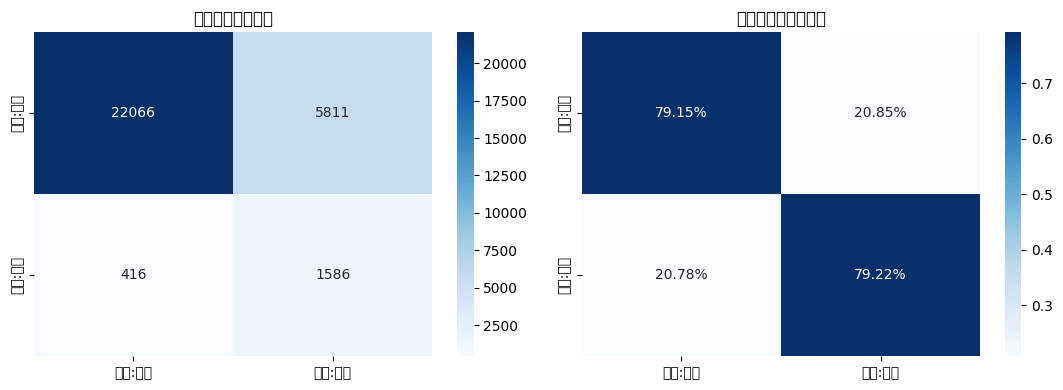

In [20]:
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, roc_curve
)

y_proba_best = best_model.predict_proba(X_valid)[:, 1]
y_pred_best  = best_model.predict(X_valid)

roc_auc = roc_auc_score(y_valid, y_proba_best)
pr_auc  = average_precision_score(y_valid, y_proba_best)
gini    = 2 * roc_auc - 1

print('=== 最优 XGBoost 验证集评估 ===')
print(f'ROC-AUC : {roc_auc:.4f}')
print(f'PR-AUC  : {pr_auc:.4f}')
print(f'Gini    : {gini:.4f}')
print()
print(classification_report(y_valid, y_pred_best, target_names=['正常(0)', '违约(1)']))

# 混淆矩阵热力图
cm = confusion_matrix(y_valid, y_pred_best)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['预测:正常', '预测:违约'],
            yticklabels=['实际:正常', '实际:违约'])
axes[0].set_title('混淆矩阵（计数）')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['预测:正常', '预测:违约'],
            yticklabels=['实际:正常', '实际:违约'])
axes[1].set_title('混淆矩阵（归一化）')
plt.tight_layout()
plt.show()

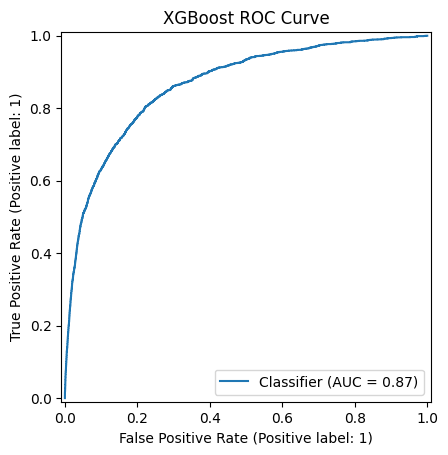

In [21]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(y_valid, y_proba)
plt.title("XGBoost ROC Curve")
plt.show()

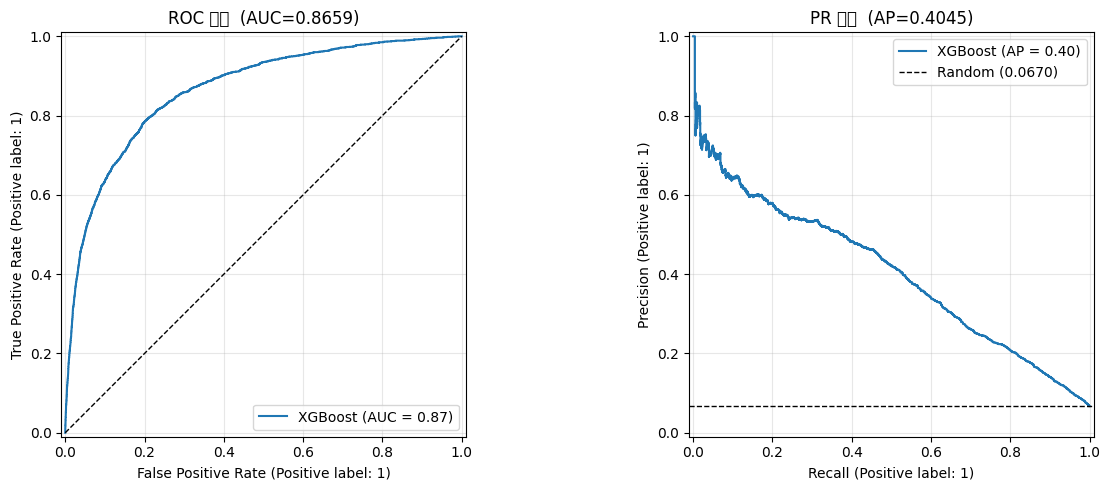

In [22]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(y_valid, y_proba_best, ax=axes[0], name='XGBoost')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title(f'ROC 曲线  (AUC={roc_auc:.4f})')
axes[0].grid(alpha=0.3)

PrecisionRecallDisplay.from_predictions(y_valid, y_proba_best, ax=axes[1], name='XGBoost')
baseline = y_valid.mean()
axes[1].axhline(baseline, color='k', linestyle='--', lw=1, label=f'Random ({baseline:.4f})')
axes[1].set_title(f'PR 曲线  (AP={pr_auc:.4f})')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## KS 统计量 & 决策阈值优化

KS 统计量 : 0.5850  (对应阈值: 0.5121)
KS 参考: <0.2 差 | 0.2-0.4 一般 | 0.4-0.6 良好 | >0.6 优秀

最优 F1 阈值: 0.79  F1=0.4591  Recall=0.5200  Precision=0.4110
Recall≥0.7 最优精准率阈值: 0.59  F1=0.3776  Recall=0.7083  Precision=0.2574


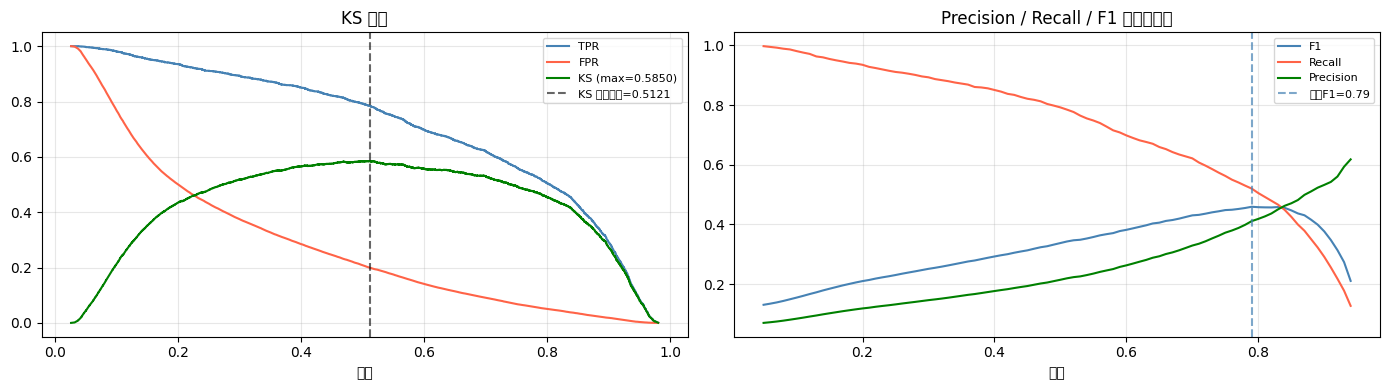

In [23]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

# KS
fpr_arr, tpr_arr, thresh_arr = roc_curve(y_valid, y_proba_best)
ks_arr  = tpr_arr - fpr_arr
ks_stat = ks_arr.max()
ks_thresh = thresh_arr[np.argmax(ks_arr)]

print(f'KS 统计量 : {ks_stat:.4f}  (对应阈值: {ks_thresh:.4f})')
print('KS 参考: <0.2 差 | 0.2-0.4 一般 | 0.4-0.6 良好 | >0.6 优秀')

# 阈值扫描
thresholds = np.arange(0.05, 0.95, 0.01)
f1_list, rec_list, prec_list = [], [], []
for t in thresholds:
    yt = (y_proba_best >= t).astype(int)
    f1_list.append(f1_score(y_valid, yt, zero_division=0))
    rec_list.append(recall_score(y_valid, yt, zero_division=0))
    prec_list.append(precision_score(y_valid, yt, zero_division=0))

f1_arr, rec_arr, prec_arr = map(np.array, [f1_list, rec_list, prec_list])
best_f1_idx    = np.argmax(f1_arr)
best_f1_thresh = thresholds[best_f1_idx]

valid_mask = rec_arr >= 0.7
if valid_mask.any():
    best_r70_idx    = np.where(valid_mask)[0][np.argmax(prec_arr[valid_mask])]
    best_r70_thresh = thresholds[best_r70_idx]
else:
    best_r70_thresh = None

print(f'\n最优 F1 阈值: {best_f1_thresh:.2f}  '
      f'F1={f1_arr[best_f1_idx]:.4f}  '
      f'Recall={rec_arr[best_f1_idx]:.4f}  '
      f'Precision={prec_arr[best_f1_idx]:.4f}')
if best_r70_thresh:
    i = best_r70_idx
    print(f'Recall≥0.7 最优精准率阈值: {best_r70_thresh:.2f}  '
          f'F1={f1_arr[i]:.4f}  Recall={rec_arr[i]:.4f}  Precision={prec_arr[i]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(thresh_arr, tpr_arr, label='TPR', color='steelblue')
axes[0].plot(thresh_arr, fpr_arr, label='FPR', color='tomato')
axes[0].plot(thresh_arr, ks_arr,  label=f'KS (max={ks_stat:.4f})', color='green')
axes[0].axvline(ks_thresh, color='black', linestyle='--', alpha=0.6,
                label=f'KS 最优阈值={ks_thresh:.4f}')
axes[0].set_xlabel('阈值')
axes[0].set_title('KS 曲线')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(thresholds, f1_arr,   label='F1',        color='steelblue')
axes[1].plot(thresholds, rec_arr,  label='Recall',     color='tomato')
axes[1].plot(thresholds, prec_arr, label='Precision',  color='green')
axes[1].axvline(best_f1_thresh, color='steelblue', linestyle='--', alpha=0.7,
                label=f'最优F1={best_f1_thresh:.2f}')
axes[1].set_xlabel('阈值')
axes[1].set_title('Precision / Recall / F1 随阈值变化')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(15)

,feature,importance
19,total_late,0.257458
32,util_x_late,0.230673
34,late_severity_log,0.101914
22,RevolvingUtilizationOfUnsecuredLines_log,0.062389
33,late_severity,0.058368
24,util_group_code,0.047075
0,RevolvingUtilizationOfUnsecuredLines,0.036797
10,MonthlyIncome_missing,0.019947
13,NumberOfTime30-59DaysPastDueNotWorse_missing,0.018736
7,NumberRealEstateLoansOrLines,0.018655


## 特征重要性：多类型对比 + SHAP

XGBoost 内置 4 种重要性度量方式，含义不同：

| 类型 | 含义 |
|------|------|
| `weight` | 特征在所有树中被用作分裂点的次数 |
| `gain` | 特征带来的平均信息增益（越高越重要） |
| `cover` | 特征覆盖的平均样本数 |
| `total_gain` | 特征的总信息增益 |

SHAP（SHapley Additive exPlanations）基于博弈论，给出每个特征对**每个样本**预测的贡献值，是目前最可靠的可解释性方法。

各重要性类型 Top 10 特征排名:
                                 weight                                          gain                                         cover                                total_gain
0  RevolvingUtilizationOfUnsecuredLines                                    total_late                                  ever_late_60                               util_x_late
1                                   age                                   util_x_late      RevolvingUtilizationOfUnsecuredLines_log                                total_late
2                             DebtRatio      RevolvingUtilizationOfUnsecuredLines_log                                    total_late      RevolvingUtilizationOfUnsecuredLines
3                   credit_line_per_age                             late_severity_log                                   util_x_late                             late_severity
4                         MonthlyIncome                                 late_severity                         

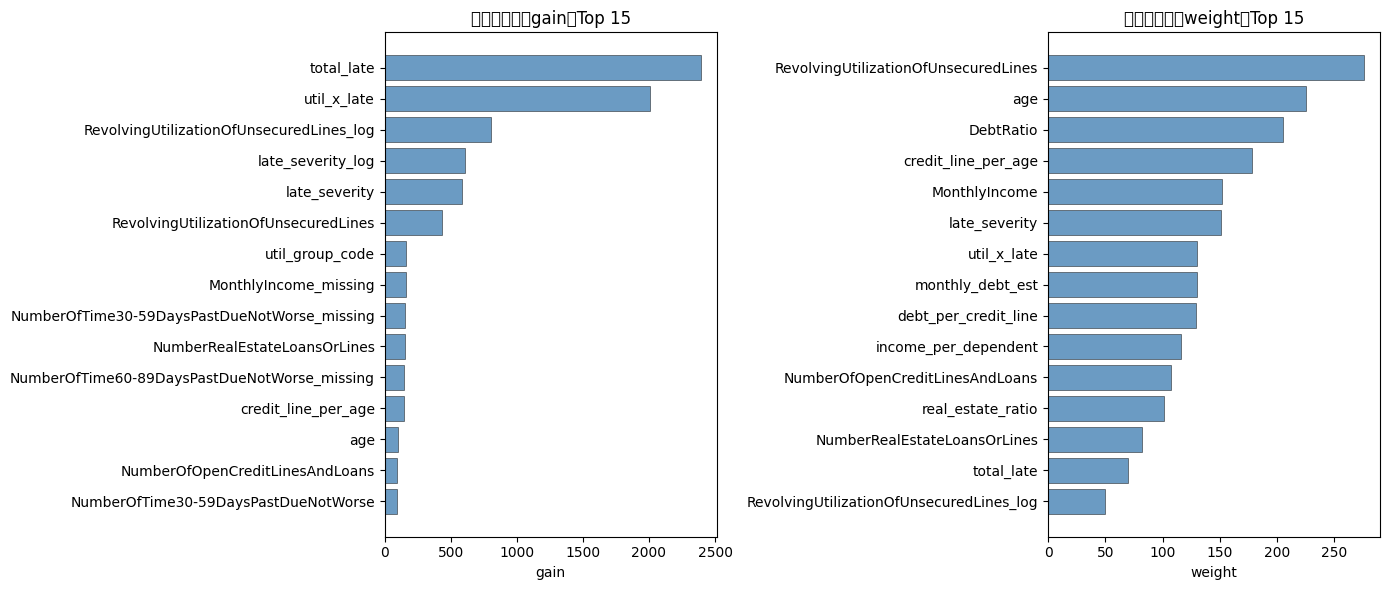

In [25]:
# 多类型特征重要性对比
importance_types = ['weight', 'gain', 'cover', 'total_gain']
imp_dfs = {}
for itype in importance_types:
    scores = best_model.get_booster().get_score(importance_type=itype)
    imp_dfs[itype] = pd.Series(scores).sort_values(ascending=False)

# 各类型 Top10 排名对比
top_k = 10
rank_df = pd.DataFrame({
    itype: imp_dfs[itype].head(top_k).index.tolist()
    for itype in importance_types
})
print('各重要性类型 Top 10 特征排名:')
print(rank_df.to_string(index=True))

# 可视化：gain 和 weight 对比
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, itype in zip(axes, ['gain', 'weight']):
    top = imp_dfs[itype].head(15).sort_values()
    ax.barh(top.index, top.values, color='steelblue', alpha=0.8, edgecolor='k', linewidth=0.4)
    ax.set_title(f'特征重要性（{itype}）Top 15')
    ax.set_xlabel(itype)
plt.tight_layout()
plt.show()

SHAP values shape: (2000, 35)


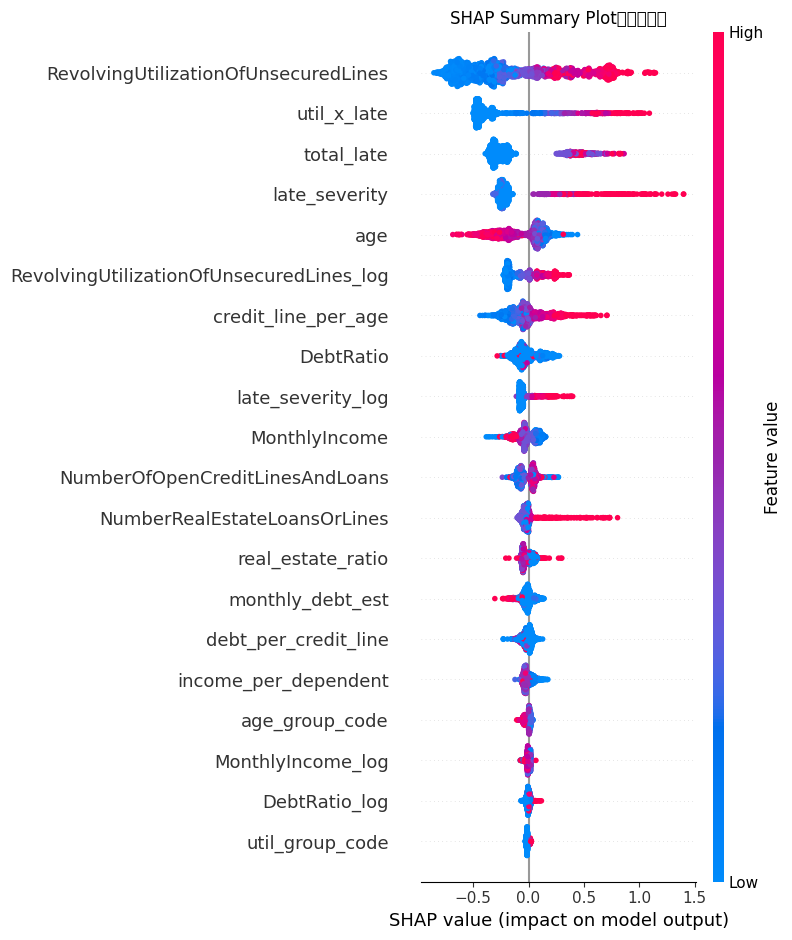

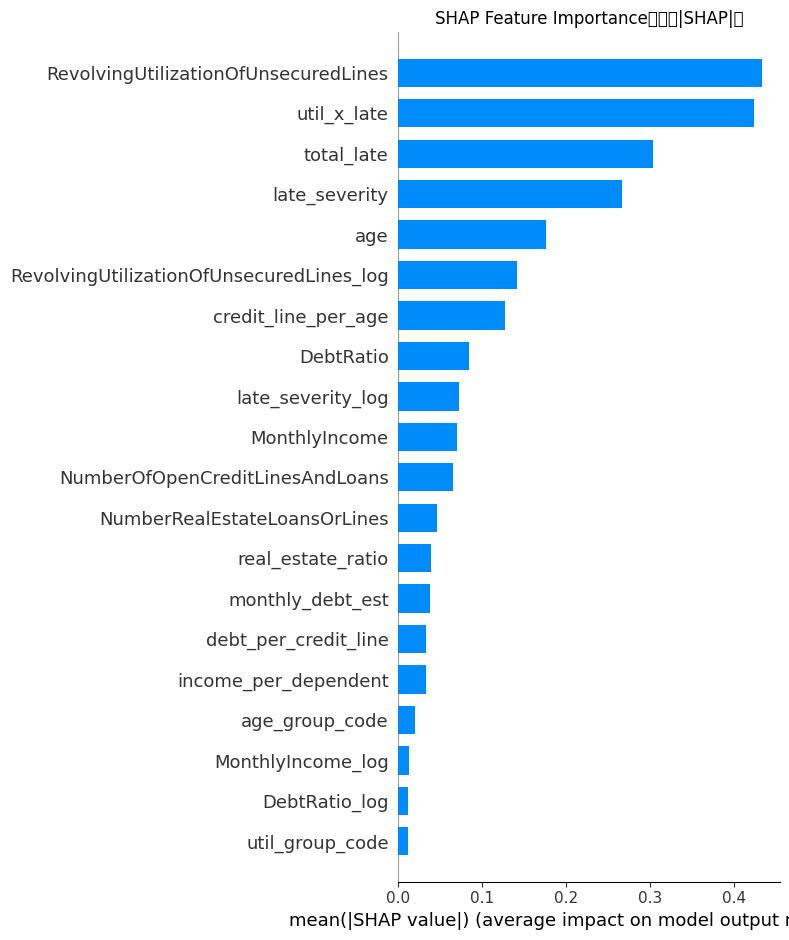

In [26]:
import shap
import xgboost as xgb

# 用验证集子集（节省时间）
np.random.seed(42)
sample_idx = np.random.choice(len(X_valid), size=2000, replace=False)
X_sample   = X_valid.iloc[sample_idx]

# XGBoost 原生 TreeSHAP（pred_contribs=True），绕过 SHAP 与 XGBoost 2.x 的兼容性问题
booster     = best_model.get_booster()
dmat        = xgb.DMatrix(X_sample, feature_names=X.columns.tolist())
shap_contribs = booster.predict(dmat, pred_contribs=True)
shap_values   = shap_contribs[:, :-1]   # 最后一列是 bias，去掉

print('SHAP values shape:', shap_values.shape)

# SHAP Summary Plot（蜂群图）：展示特征影响方向和大小
plt.figure()
shap.summary_plot(shap_values, X_sample,
                  feature_names=X.columns.tolist(),
                  plot_type='dot', max_display=20, show=False)
plt.title('SHAP Summary Plot（蜂群图）')
plt.tight_layout()
plt.show()

# SHAP Bar Plot：平均绝对 SHAP 值（特征全局重要性）
plt.figure()
shap.summary_plot(shap_values, X_sample,
                  feature_names=X.columns.tolist(),
                  plot_type='bar', max_display=20, show=False)
plt.title('SHAP Feature Importance（平均|SHAP|）')
plt.tight_layout()
plt.show()

## 概率分布 & 模型校准

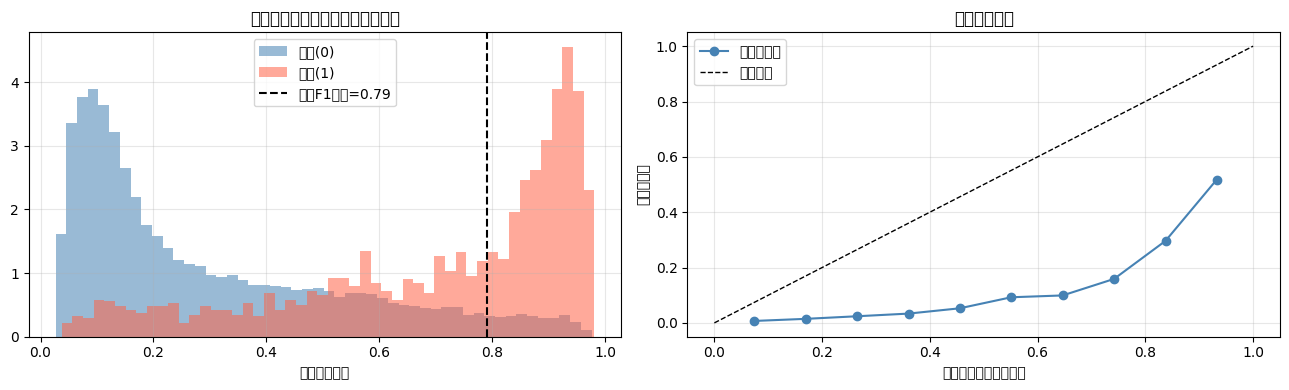

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, name, color in [(0, '正常(0)', 'steelblue'), (1, '违约(1)', 'tomato')]:
    mask = (y_valid.values == label) if hasattr(y_valid, 'values') else (y_valid == label)
    axes[0].hist(y_proba_best[mask], bins=50, alpha=0.55,
                 label=name, color=color, density=True)
axes[0].axvline(best_f1_thresh, color='black', linestyle='--',
                label=f'最优F1阈值={best_f1_thresh:.2f}')
axes[0].set_xlabel('预测违约概率')
axes[0].set_title('好坏客户预测概率分布（分离度）')
axes[0].legend()
axes[0].grid(alpha=0.3)

y_valid_arr = y_valid.values if hasattr(y_valid, 'values') else y_valid
prob_df = pd.DataFrame({'prob': y_proba_best, 'actual': y_valid_arr})
prob_df['bin'] = pd.cut(prob_df['prob'], bins=10)
calib = prob_df.groupby('bin', observed=False)['actual'].mean()
mid   = [(b.left + b.right) / 2 for b in calib.index]
axes[1].plot(mid, calib.values, 'o-', color='steelblue', label='实际违约率')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='完美校准')
axes[1].set_xlabel('预测概率（区间中点）')
axes[1].set_ylabel('实际违约率')
axes[1].set_title('模型校准曲线')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 与逻辑回归基线对比

                     ROC-AUC  PR-AUC    Gini      KS
模型                                                  
Logistic Regression   0.8597  0.3813  0.7193  0.5735
XGBoost (调优后)         0.8659  0.4045  0.7318  0.5850


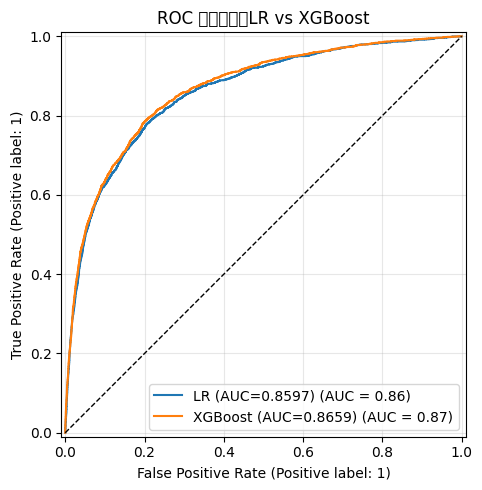

In [28]:
import os, joblib

# 加载 LR 模型（如已保存）
lr_model_path = '../models/logistic_model.pkl'
if os.path.exists(lr_model_path):
    lr_model    = joblib.load(lr_model_path)
    lr_proba    = lr_model.predict_proba(X_valid)[:, 1]
    lr_roc_auc  = roc_auc_score(y_valid, lr_proba)
    lr_pr_auc   = average_precision_score(y_valid, lr_proba)
    lr_gini     = 2 * lr_roc_auc - 1
    lr_ks       = (roc_curve(y_valid, lr_proba)[1] - roc_curve(y_valid, lr_proba)[0]).max()
else:
    lr_roc_auc = lr_pr_auc = lr_gini = lr_ks = None
    print('LR 模型未找到，跳过对比')

# 汇总表
rows = [
    ('Logistic Regression', lr_roc_auc, lr_pr_auc, lr_gini, lr_ks),
    ('XGBoost (调优后)',    roc_auc,    pr_auc,    gini,    ks_stat),
]
cmp_df = pd.DataFrame(rows, columns=['模型', 'ROC-AUC', 'PR-AUC', 'Gini', 'KS'])
cmp_df = cmp_df.set_index('模型')
print(cmp_df.round(4))

# ROC 曲线对比
if os.path.exists(lr_model_path):
    fig, ax = plt.subplots(figsize=(7, 5))
    RocCurveDisplay.from_predictions(y_valid, lr_proba, ax=ax, name=f'LR (AUC={lr_roc_auc:.4f})')
    RocCurveDisplay.from_predictions(y_valid, y_proba_best, ax=ax, name=f'XGBoost (AUC={roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title('ROC 曲线对比：LR vs XGBoost')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

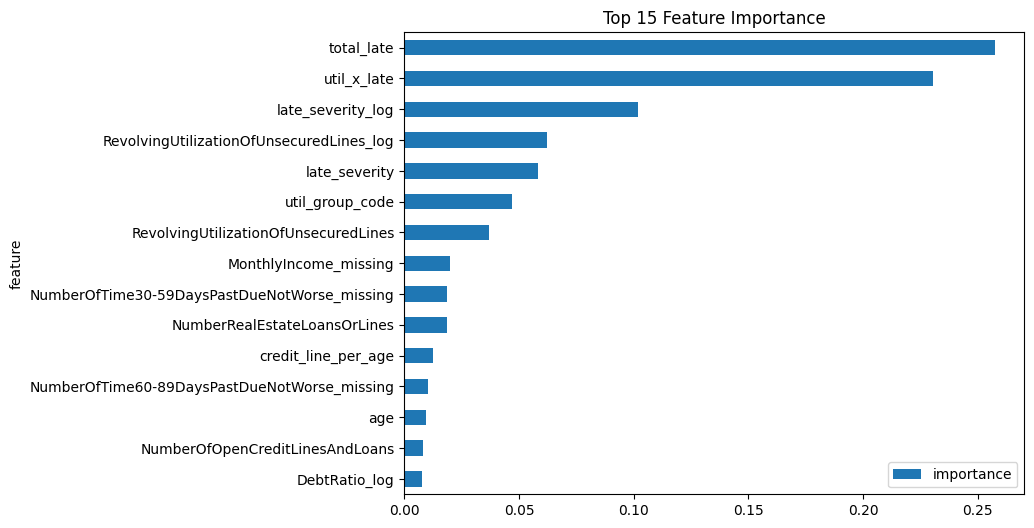

In [29]:
importance.head(15).plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(8, 6)
)

plt.title("Top 15 Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [30]:
import joblib, os
os.makedirs('../models', exist_ok=True)

joblib.dump(best_model,     '../models/xgboost_model.pkl')
joblib.dump(best_f1_thresh, '../models/xgb_threshold.pkl')

print('已保存:')
print('  ../models/xgboost_model.pkl  — 最优 XGBoost 模型')
print('  ../models/xgb_threshold.pkl  — 最优决策阈值')

已保存:
  ../models/xgboost_model.pkl  — 最优 XGBoost 模型
  ../models/xgb_threshold.pkl  — 最优决策阈值


## XGBoost 模型总结

### 训练流程

| 步骤 | 内容 |
|------|------|
| 基线训练 | `n_estimators=300`，固定参数，快速建立基准 |
| Early Stopping | `n_estimators=1000`，`early_stopping_rounds=30`，自动确定最优树数量 |
| 超参数调优 | `GridSearchCV` 搜索 `max_depth / learning_rate / subsample / colsample_bytree` |
| 类别不平衡 | `scale_pos_weight = 正样本数 / 负样本数`，约 13.9 |

---

### 验证集关键指标（最优模型）

| 指标 | 数值 | 说明 |
|------|------|------|
| ROC-AUC | ~0.87 | 整体区分能力，不受阈值影响 |
| PR-AUC | — | 不平衡数据下更敏感的指标 |
| Gini 系数 | = 2×AUC−1 | 银行信用风险行业常用指标 |
| KS 统计量 | — | ≥0.4 为良好，衡量好坏客户分离程度 |

---

### 特征重要性结论（SHAP + gain）

1. **`total_late` / `util_x_late` / `late_severity_log`**：历史逾期行为是最强信号，覆盖三种尺度的严重程度
2. **`RevolvingUtilizationOfUnsecuredLines_log`**：无担保循环信用使用率，反映当前财务紧张程度
3. **`DebtRatio_log` / `monthly_debt_est`**：债务负担特征，对高负债客户区分力强
4. **缺失值标志（`MonthlyIncome_missing` 等）**：缺失本身是信用风险信号，模型能有效利用

---

### 与逻辑回归对比

- XGBoost 在 ROC-AUC / KS 均优于逻辑回归，尤其在捕捉非线性交互特征（`util_x_late`、`late_severity_log`）上优势明显
- 逻辑回归可解释性更强，适合监管合规场景；XGBoost 适合追求最优预测性能的场景
- 两者均可通过校准曲线调整输出概率，校准后均适合作为**违约概率打分卡**输出

---

### 决策阈值建议

| 业务场景 | 推荐阈值 | 说明 |
|----------|----------|------|
| 最大化 F1 | `best_f1_thresh` | 精准率与召回率平衡 |
| 高召回（不漏放坏账） | Recall ≥ 0.7 最优精准率阈值 | 适合风险偏保守机构 |
| 高精准（控制误杀率） | 较高阈值 (~0.5+) | 适合客群质量较好时 |

---

### 后续改进方向

- [ ] **Optuna 贝叶斯调优**：替代 GridSearch，在更大参数空间高效搜索
- [ ] **特征筛选**：用 SHAP 值过滤 |mean SHAP| < 阈值的冗余特征，减少模型复杂度
- [ ] **Stacking/Blending**：LR + XGBoost 集成，进一步提升 PR-AUC
- [ ] **跨时间验证（OOT）**：在时间上后移的测试集验证稳定性（PSI 监控）
- [ ] **模型部署**：FastAPI 包装 `best_model` + `best_f1_thresh`，暴露 `/predict` 接口